# Lab 6: Practical Recommender Systems

## Section 1: Building a DL based RS

In [3]:
!pip install scikit-surprise
!pip install --upgrade scikit-surprise
!pip install numpy==1.24.3
!pip install --upgrade numpy==1.24.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505217 sha256=82352503844e0788a869d3588750c0e1eb604765c8888d2f87c09f0560ad848c
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 105.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.21.1 requires numpy>=1.25.0, but you have numpy 1

Surprise is a Python scikit for building and analyzing recommender systems that deal with explicit rating data: https://surpriselib.com/

In [1]:
!pip uninstall scikit-surprise numpy -y
!pip install numpy==1.24.3
!pip install scikit-surprise

Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
Found existing installation: numpy 1.24.3
Uninstalling numpy-1.24.3:
  Successfully uninstalled numpy-1.24.3
  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.21.1 requires numpy>=1.25.0, but you have numpy 1.24.3 which is incompatible.
blosc2 3.2.0 requires numpy>=1.26, but you have numpy 1.24.3 which is incompatible.
albucore 0.0.23 requires numpy>=1.24.4, but you have numpy 1.24.3 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.3 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25

  Using cached scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl


In [21]:
from surprise import Dataset
import numpy as np
import numpy.core.multiarray

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils import shuffle
import pandas as pd
import pprint

### We first need to define a data loader

In [22]:
class Loader():
    current = 0

    def __init__(self, x, y, batch_size=2048, is_shuffle=True):
        from sklearn.utils import shuffle
        self.shuffle = shuffle
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.batches = range(0, len(self.y), batch_size)

        # If is_shuffle, we re-shuffle on every epoch
        if is_shuffle:
            self.x, self.y = shuffle(self.x, self.y)

    def __iter__(self):
        # Reset and return a new iterator
        self.x, self.y = shuffle(self.x, self.y, random_state=0)
        self.current = 0
        return self

    def __len__(self):
        # Return the number of batches
        return int(len(self.x) / self.batch_size)

    def __next__(self):
        n = self.batch_size

        if self.current + n >= len(self.y):
            raise StopIteration

        i = self.current
        xs = torch.from_numpy(self.x[i:i + n])
        ys = torch.from_numpy(self.y[i:i + n])

        self.current += n

        return (xs, ys)

### Let us build a Matrix Factorization (MF) model using PyTorch

(Optional) Homework: You can try other models such as Multi-layerd Perceptrons (MLP), Neural Collaborative Filtering (NeuMF)

In [23]:
class MF(nn.Module):

    def __init__(self, n_user, n_item, k=18, c_vector=1.0, c_bias=1.0):
        super(MF, self).__init__()
        self.k = k
        self.n_user = n_user
        self.n_item = n_item
        self.c_bias = c_bias
        self.c_vector = c_vector

        self.user = nn.Embedding(n_user, k)
        self.item = nn.Embedding(n_item, k)

        # We add new terms here:
        self.bias_user = nn.Embedding(n_user, 1)
        self.bias_item = nn.Embedding(n_item, 1)

        self.bias = nn.Parameter(torch.ones(1))

    def forward(self, train_x):
        user_id = train_x[:, 0]
        item_id = train_x[:, 1]

        vector_user = self.user(user_id)
        vector_item = self.item(item_id)

        # Pull out biases
        bias_user = self.bias_user(user_id).squeeze()
        bias_item = self.bias_item(item_id).squeeze()

        biases = self.bias + bias_user + bias_item

        ui_interaction = torch.sum(vector_user * vector_item, dim=1)

        # Add bias prediction to the interaction prediction
        prediction = ui_interaction + biases
        return prediction

    def loss(self, prediction, target):

        def l2_regularize(array):
            loss = torch.sum(array**2)
            return loss

        loss_mse = F.mse_loss(prediction, target.squeeze())

        # Add new regularization to the biases
        prior_bias_user =  l2_regularize(self.bias_user.weight) * self.c_bias
        prior_bias_item = l2_regularize(self.bias_item.weight) * self.c_bias

        prior_user =  l2_regularize(self.user.weight) * self.c_vector
        prior_item = l2_regularize(self.item.weight) * self.c_vector

        total = loss_mse + prior_bias_user + prior_bias_item + prior_user + prior_item
        return total

### Finally, we define the main() function

In [24]:
def main():
    # Get data
    data = Dataset.load_builtin('ml-1m')
    trainset = data.build_full_trainset()
    uir = np.array([x for x in trainset.all_ratings()])

    train_x = test_x = uir[:,:2].astype(np.int64)
    train_y = test_y = uir[:,2].astype(np.float32)

    # Define parameters
    lr = 1e-1 # learning rate
    k = 10  # embedding size or latent dimension
    c_bias = 1e-6
    c_vector = 1e-6
    batch_size = 2048

    model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)

    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    dataloader = Loader(train_x, train_y, batch_size=batch_size)

    itr = 0
    for batch in dataloader:

        itr += 1

        prediction = model(batch[0])
        loss = model.loss(prediction,batch[1])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"iteration: {itr}. training loss: {loss}")

    torch.save(model.state_dict(), "./recommendation_model_pytorch.pkl")

if __name__=='__main__':
    main()

iteration: 1. training loss: 20.929075241088867
iteration: 2. training loss: 17.264253616333008
iteration: 3. training loss: 14.135551452636719
iteration: 4. training loss: 13.783329010009766
iteration: 5. training loss: 12.037456512451172
iteration: 6. training loss: 11.917482376098633
iteration: 7. training loss: 10.788152694702148
iteration: 8. training loss: 9.817270278930664
iteration: 9. training loss: 8.776541709899902
iteration: 10. training loss: 8.636564254760742
iteration: 11. training loss: 7.6031670570373535
iteration: 12. training loss: 7.287537574768066
iteration: 13. training loss: 6.614277362823486
iteration: 14. training loss: 6.561183452606201
iteration: 15. training loss: 5.996102333068848
iteration: 16. training loss: 5.734259605407715
iteration: 17. training loss: 5.462621688842773
iteration: 18. training loss: 5.627216815948486
iteration: 19. training loss: 5.213529586791992
iteration: 20. training loss: 4.798162460327148
iteration: 21. training loss: 4.800444602

## Section 2: Now we're ready to do inference

For inference, we will use most of the code from before (especially the model definition).

In [25]:
from surprise import Dataset
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import pprint

In [26]:
# This function aims to get the top-N recommendations

def get_top_n(model, testset, trainset, uid_input, movies_df, n=10):

    preds = []
    try:
        uid_input = int(trainset.to_inner_uid(uid_input))
    except KeyError:
        return preds

    # We first map the predictions to each user.
    for uid, iid, _ in testset:
        try:
            uid_internal = int(trainset.to_inner_uid(uid))
        except KeyError:
            continue

        if uid_internal == uid_input:
            try:
                iid_internal = int(trainset.to_inner_iid(iid))
                movie_name = movies_df.loc[int(iid), 'name']
                preds.append((iid, movie_name, float(model(torch.tensor([[uid_input, iid_internal]])))))
            except KeyError:
                pass

    # Then, we sort the predictions for each user and retrieve the k highest ones (i.e., top-K recommendations)
    if preds is not None:
        preds.sort(key=lambda x: x[1], reverse=True)
        if len(preds) > n:
            preds = preds[:n]
    return preds

In [27]:
# This function aims to get previously seen items (i.e., items that user has already seen in the past)

def get_previously_seen(trainset, uid, movies_df):
    seen = []
    for (iid, _) in trainset.ur[int(uid)]:
        try:
            seen.append(movies_df.loc[int(iid)]['name'])
        except KeyError:
            pass
        if len(seen) > 10:
            break
    return seen

In [28]:
def main():
    data = Dataset.load_builtin('ml-1m')

    import os
    files_dir = os.path.expanduser("/root/.surprise_data/ml-1m/ml-1m/")

    movies_df = pd.read_csv(files_dir + 'movies.dat', sep='::', header=None, engine='python', encoding='latin-1')
    movies_df.columns = ['iid','name','genre']
    movies_df.set_index('iid',inplace=True)

    trainset = data.build_full_trainset()
    testset = trainset.build_anti_testset()

    k = 10 # embedding size or latent dimension
    c_bias = 1e-6
    c_vector = 1e-6

    model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)
    model.load_state_dict(torch.load('./recommendation_model_pytorch.pkl'))
    model.eval()

    # Let us print the recommended items for some sample users
    sample_users = list(set([x[0] for x in testset]))[:4]

    for uid in sample_users:

        print('User:',uid)
        print('\n')

        print('\tSeen:')
        seen = get_previously_seen(trainset, uid, movies_df)
        pprint.pprint(seen)
        print('\n')

        print('\tRecommendations:')
        recommended = get_top_n(model, testset, trainset, uid, movies_df, n=10)
        pprint.pprint([x[1] for x in recommended])
        print('\n')



if __name__=="__main__":
    main()

User: 4476


	Seen:
['Forget Paris (1995)',
 'Mask of Zorro, The (1998)',
 'Hate (Haine, La) (1995)',
 'Jerky Boys, The (1994)',
 "Jupiter's Wife (1994)",
 'Wife, The (1995)',
 'B. Monkey (1998)',
 'Willy Wonka and the Chocolate Factory (1971)',
 'Man of No Importance, A (1994)',
 'Star Trek V: The Final Frontier (1989)',
 'They Bite (1996)']


	Recommendations:
['eXistenZ (1999)',
 'Zeus and Roxanne (1997)',
 'Zero Kelvin (Kjærlighetens kjøtere) (1995)',
 'Zero Effect (1998)',
 'Zed & Two Noughts, A (1985)',
 'Zachariah (1971)',
 'Your Friends and Neighbors (1998)',
 'Young and Innocent (1937)',
 'Young Sherlock Holmes (1985)',
 "Young Poisoner's Handbook, The (1995)"]


User: 2887


	Seen:
['Boys on the Side (1995)',
 'Stalker (1979)',
 '20,000 Leagues Under the Sea (1954)',
 'Palookaville (1996)',
 'Amityville II: The Possession (1982)',
 'Forget Paris (1995)',
 'Pagemaster, The (1994)',
 'Amityville Curse, The (1990)',
 'Nadja (1994)',
 'Sleepover (1995)',
 'Last Summer in the Hamp

## Section 3: Model Serving and MLOps

Flask is a micro web framework written in Python. Function decorators are used in Flask to achieve routes to functions mapping. We first show how a simple service works, and then show how to load a model (e.g., based on pytorch) and serve it as well.

In [29]:
 # load Flask
import flask
import time
import os

app = flask.Flask(__name__)

Unlike running Flask on a local machine, Google Colab provides you with a Virtual Machine (VM) whose localhost:5000 (Server Address for Flask Server and Default port) cannot be accessed directly. Therefore, the solution is to expose this address to a public url. To do this, a simple piece of code must be run before starting your server.

In [30]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://mn7irzx77ia-496ff2e9c6d22116-5000-colab.googleusercontent.com/


In [31]:
start_time = time.time()

# Load data
data = Dataset.load_builtin('ml-1m')
trainset = data.build_full_trainset()
testset = trainset.build_anti_testset()

files_dir = os.path.expanduser("/root/.surprise_data/ml-1m/ml-1m/")

movies_df = pd.read_csv(files_dir + 'movies.dat', sep='::', header=None, engine='python', encoding='latin-1')
movies_df.columns = ['iid', 'name', 'genre']
movies_df.set_index('iid', inplace=True)

# Load model
k = 10
c_bias = 1e-6
c_vector = 1e-6
model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)
model.load_state_dict(torch.load('./recommendation_model_pytorch.pkl'))
model.eval()

print('Model and data preloading completed in ', time.time()-start_time)

@app.route("/", methods=["GET"])
def recommend():

    data = {"success": False}

    if "uid" in flask.request.args:

        data['uid'] = str(flask.request.args['uid'])

        try:
            data['seen'] = get_previously_seen(trainset, data['uid'], movies_df)
            recommended = get_top_n(model, testset, trainset, data['uid'], movies_df, n=10)
            print(recommended)
            data['recommended'] = [x[1] for x in recommended]
            data["success"] = True
        except:
            pass

    return flask.jsonify(data)

# start the flask app, allow remote connections
if __name__ == '__main__':
    app.run(host='0.0.0.0')

Model and data preloading completed in  10.794958353042603
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


For example, to get the recommendation results of the user id 200 (i.e., uid=200), we can observe it here:

https://cj1q70zbou-496ff2e9c6d22116-5000-colab.googleusercontent.com/?uid=200

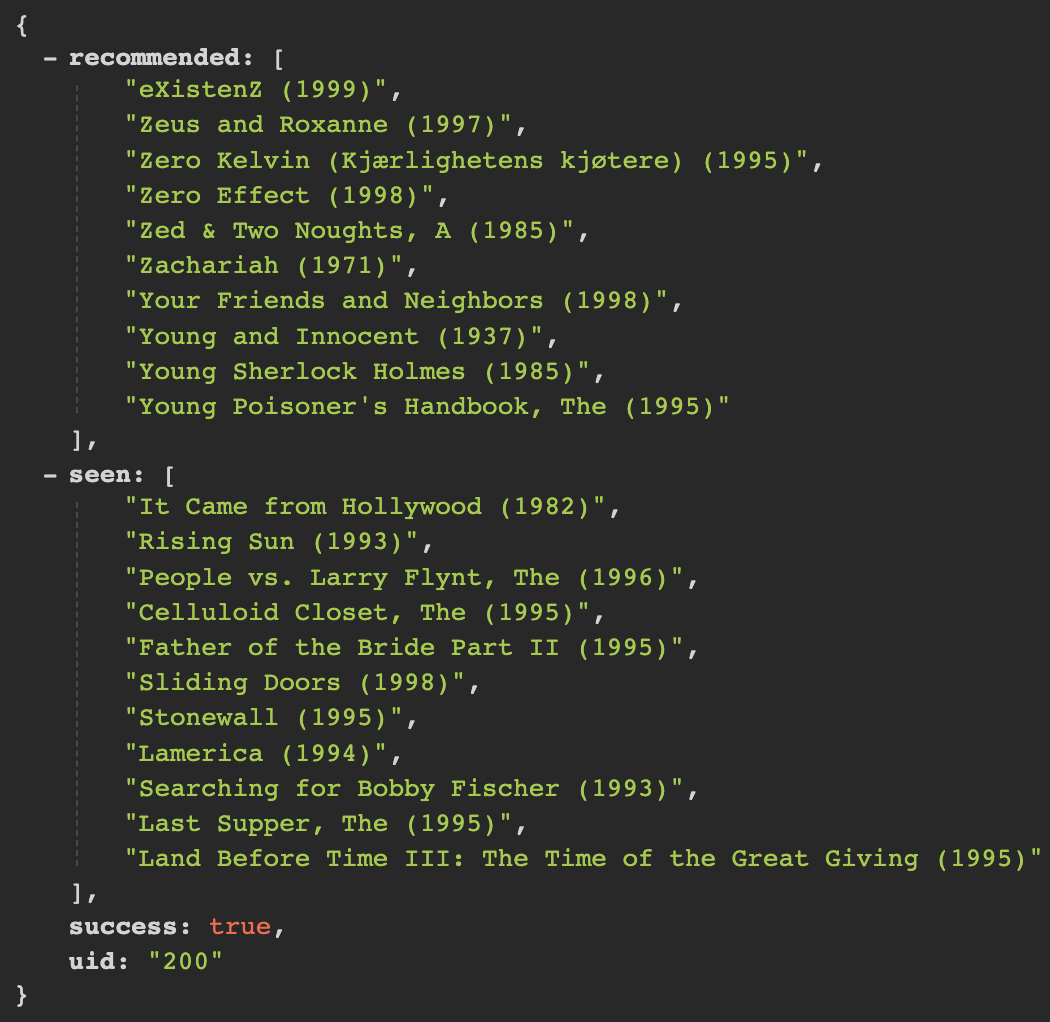

## Section 4: (Manually) Tune Parameters

Let us manually tune the parameters (i.e., lr and k in our case) to see if we can improve any performances.

Note that in real-life scenarios, we can do hyperparmeter search or hyperparameter optimization

https://en.wikipedia.org/wiki/Hyperparameter_optimization

In [32]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://mn7irzx77ia-496ff2e9c6d22116-5000-colab.googleusercontent.com/


In [33]:
def main():
    # get data
    data = Dataset.load_builtin('ml-1m')
    trainset = data.build_full_trainset()
    uir = np.array([x for x in trainset.all_ratings()])

    train_x = test_x = uir[:,:2].astype(np.int64)
    train_y = test_y = uir[:,2].astype(np.float32)

    # define parameters
    lr = 0.1
    k=64
    c_bias = 1e-6
    c_vector = 1e-6
    batch_size = 2048

    model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    dataloader = Loader(train_x, train_y, batch_size=batch_size)

    itr = 0
    for batch in dataloader:
      itr +=1

      prediction = model(batch[0])
      loss = model.loss(prediction, batch[1])

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      print(f"iteration: {itr}. training loss: {loss}")

    torch.save(model.state_dict(), "./recommendation_model_pytorch_new.pkl")

if __name__=='__main__':
    main()

iteration: 1. training loss: 73.76412963867188
iteration: 2. training loss: 64.70426940917969
iteration: 3. training loss: 60.458961486816406
iteration: 4. training loss: 58.33647918701172
iteration: 5. training loss: 55.104148864746094
iteration: 6. training loss: 52.34141540527344
iteration: 7. training loss: 49.701202392578125
iteration: 8. training loss: 49.6922607421875
iteration: 9. training loss: 45.6522216796875
iteration: 10. training loss: 46.81904602050781
iteration: 11. training loss: 43.568485260009766
iteration: 12. training loss: 43.611053466796875
iteration: 13. training loss: 43.87128829956055
iteration: 14. training loss: 44.467533111572266
iteration: 15. training loss: 40.56462478637695
iteration: 16. training loss: 38.24734115600586
iteration: 17. training loss: 40.21438217163086
iteration: 18. training loss: 39.184452056884766
iteration: 19. training loss: 39.43674087524414
iteration: 20. training loss: 37.822566986083984
iteration: 21. training loss: 37.5678863525

We now load the new pickle file (i.e., recommendation_model_pytorch_new.pkl) to do inference

In [34]:
def main():
    data = Dataset.load_builtin('ml-1m')

    files_dir = os.path.expanduser("/root/.surprise_data/ml-1m/ml-1m/")

    movies_df = pd.read_csv(files_dir + 'movies.dat', sep="::", header=None, engine='python', encoding='latin-1')
    movies_df.columns = ['iid', 'title', 'genres']
    movies_df.set_index('iid', inplace=True)

    trainset = data.build_full_trainset()
    testset = trainset.build_anti_testset()

    k = 64
    c_bias=1e-6
    c_vector=1e-6

    model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)
    model.load_state_dict(torch.load('./recommendation_model_pytorch_new.pkl'))
    model.eval()

    sample_users = list(set([x[0] for x in testset]))[:4]

    for uid in sample_users:

        print('User:',uid)
        print('\n')

        print('\tSeen:')
        seen = get_previously_seen(trainset, uid, movies_df)
        pprint.pprint(seen)
        print('\n')

        print('\tRecommendations:')
        recommended = get_top_n(model, testset, trainset, uid, movies_df, n=10)
        pprint.pprint([x[1] for x in recommended])
        print('\n')



if __name__=="__main__":
    main()

User: 4476


	Seen:
[]


	Recommendations:
[]


User: 2887


	Seen:
[]


	Recommendations:
[]


User: 3400


	Seen:
[]


	Recommendations:
[]


User: 1934


	Seen:
[]


	Recommendations:
[]




Finally, let us serve our model and see how.

In [35]:
start_time = time.time()

# Load data
data = Dataset.load_builtin('ml-1m')
trainset = data.build_full_trainset()
testset = trainset.build_anti_testset()

files_dir = os.path.expanduser("/root/.surprise_data/ml-1m/ml-1m/")

movies_df = pd.read_csv(files_dir + 'movies.dat', sep="::", header=None, engine='python', encoding='latin-1')
movies_df.columns = ['iid', 'title', 'genres']
movies_df.set_index('iid', inplace=True)

# Load model
k = 64 # 64 instead of 10
c_bias = 1e-6
c_vector = 1e-6
model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)
model.load_state_dict(torch.load('./recommendation_model_pytorch_new.pkl'))
model.eval()

print('Model and data preloading completed in ', time.time()-start_time)

@app.route("/", methods=["GET"])
def recommend_new():

    data = {"success": False}

    if "uid" in flask.request.args:

      data['uid'] = str(flask.request.args['uid'])

      try:
        data['seen'] = get_previously_seen(trainset, data['uid'], movies_df)
        recommended = get_top_n(model, testset, trainset, data['uid'], movies_df, n=10)
        print(recommended)
        data['recommended'] = [x[1] for x in recommended]
        data["success"] = True

      except Exception as e:
        print(e)
        data['error'] = str(e)
        pass

    return flask.jsonify(data)

# start the flask app, allow remote connections
if __name__ == '__main__':
    app.run(host='0.0.0.0')

Model and data preloading completed in  10.538735151290894
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


# End of Lab!

Reference:

[1] University of Illinois Chicago. MLOps 2020 from Theja.